<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/02.circuits-and-encoding/02.feature-encoding/28_phase_interference_measurement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day16 phase interference 측정 실습

- Source: Google Drive `Day16/3-4.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Phase Angle
Phase = 1.0472 rad

STEP 2. Circuit A
     ┌───┐┌────────┐┌─┐
  q: ┤ H ├┤ P(π/3) ├┤M├
     └───┘└────────┘└╥┘
c: 1/════════════════╩═
                     0 

STEP 3. Circuit B
     ┌───┐┌────────┐┌───┐┌─┐
  q: ┤ H ├┤ P(π/3) ├┤ H ├┤M├
     └───┘└────────┘└───┘└╥┘
c: 1/═════════════════════╩═
                          0 

STEP 4. Simulation


Circuit A
{'0': 2064, '1': 2032}

Circuit B
{'0': 3070, '1': 1026}

STEP 5. Histogram

STEP 6. Multiple Phase



STEP 7. Theory

STEP 8. Graph


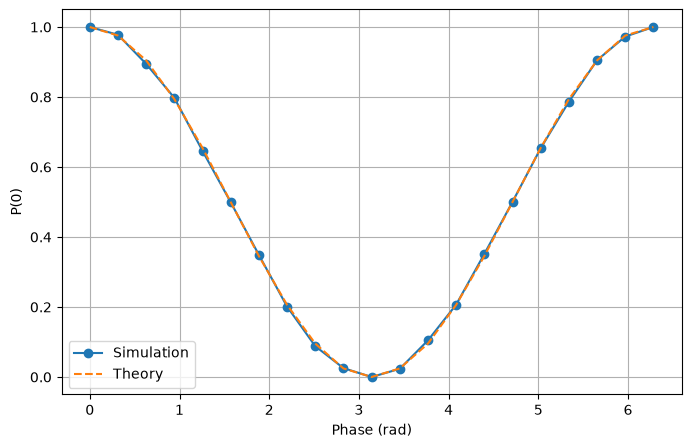

Lab 4 Complete


In [1]:
"""
============================================================
Lab 4.
Measurement와 Interference 비교
============================================================

실습 순서
------------------------------------------------------------
STEP 1. Import Library
STEP 2. Phase 값 준비
STEP 3. Circuit A (H → P → Measure)
STEP 4. Circuit B (H → P → H → Measure)
STEP 5. AerSimulator 실행
STEP 6. Histogram 비교
STEP 7. 다양한 Phase 실험
STEP 8. Cos² 함수 비교
STEP 9. 결과 분석
============================================================
"""

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit import transpile

from qiskit_aer import AerSimulator

from qiskit.visualization import plot_histogram

# ============================================================
# STEP 1.
# Phase Angle
# ============================================================

print("="*80)
print("STEP 1. Phase Angle")
print("="*80)

phi = np.pi/3

print(f"Phase = {phi:.4f} rad")

# ============================================================
# STEP 2.
# Circuit A
# H → P → Measure
# ============================================================

print()
print("="*80)
print("STEP 2. Circuit A")
print("="*80)

qc1 = QuantumCircuit(1,1)

qc1.h(0)

qc1.p(phi,0)

qc1.measure(0,0)

print(qc1.draw())

# ============================================================
# STEP 3.
# Circuit B
# H → P → H → Measure
# ============================================================

print()
print("="*80)
print("STEP 3. Circuit B")
print("="*80)

qc2 = QuantumCircuit(1,1)

qc2.h(0)

qc2.p(phi,0)

qc2.h(0)

qc2.measure(0,0)

print(qc2.draw())

# ============================================================
# STEP 4.
# Simulator
# ============================================================

print()
print("="*80)
print("STEP 4. Simulation")
print("="*80)

backend = AerSimulator()

shots = 4096

tqc1 = transpile(qc1,backend)

tqc2 = transpile(qc2,backend)

result1 = backend.run(
    tqc1,
    shots=shots
).result()

result2 = backend.run(
    tqc2,
    shots=shots
).result()

counts1 = result1.get_counts()

counts2 = result2.get_counts()

print("Circuit A")

print(counts1)

print()

print("Circuit B")

print(counts2)

# ============================================================
# STEP 5.
# Histogram
# ============================================================

print()
print("="*80)
print("STEP 5. Histogram")
print("="*80)

plot_histogram(

    [counts1,counts2],

    legend=[
        "H-P",
        "H-P-H"
    ]

)

plt.show()

# ============================================================
# STEP 6.
# 다양한 Phase 실험
# ============================================================

print()
print("="*80)
print("STEP 6. Multiple Phase")
print("="*80)

phase_list = np.linspace(

    0,
    2*np.pi,
    21

)

prob0 = []

backend = AerSimulator()

for phase in phase_list:

    qc = QuantumCircuit(1,1)

    qc.h(0)

    qc.p(phase,0)

    qc.h(0)

    qc.measure(0,0)

    tqc = transpile(qc,backend)

    result = backend.run(

        tqc,
        shots=4096

    ).result()

    counts = result.get_counts()

    p0 = counts.get("0",0)/4096

    prob0.append(p0)

# ============================================================
# STEP 7.
# Cos² 이론값
# ============================================================

print()
print("="*80)
print("STEP 7. Theory")
print("="*80)

theory = np.cos(

    phase_list/2

)**2

# ============================================================
# STEP 8.
# 그래프 비교
# ============================================================

print()
print("="*80)
print("STEP 8. Graph")
print("="*80)

plt.figure(figsize=(8,5))

plt.plot(

    phase_list,

    prob0,

    "o-",

    label="Simulation"

)

plt.plot(

    phase_list,

    theory,

    "--",

    label="Theory"

)

plt.xlabel("Phase (rad)")

plt.ylabel("P(0)")

plt.grid(True)

plt.legend()

plt.show()

print("="*80)
print("Lab 4 Complete")
print("="*80)